# Fire Detection using PyTorch Mask R-CNN

This notebook implements fire detection using PyTorch's built-in Mask R-CNN implementation from torchvision, which is actively maintained and compatible with modern Python versions.


In [15]:
# Install required packages from requirements.txt

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from PIL import Image
import random
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0
Torchvision version: 0.23.0
CUDA available: False


In [ ]:
# Set paths and configurations
ROOT_DIR = "/Users/Documents/image_segmentation/image-seg-mask-rcnn"
TRAIN_DIR = os.path.join(ROOT_DIR, "input/dataset/train")
VAL_DIR = os.path.join(ROOT_DIR, "input/dataset/val")
TEST_DIR = os.path.join(ROOT_DIR, "input/dataset/test")
MODEL_SAVE_PATH = os.path.join(ROOT_DIR, "output/pytorch_maskrcnn_fire.pth")

# Training configuration
NUM_CLASSES = 2  # background + fire
BATCH_SIZE = 2
NUM_EPOCHS = 20
LEARNING_RATE = 0.005
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

# Set device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


In [18]:
class FireDataset(Dataset):
    def __init__(self, data_dir, transforms=None):
        self.data_dir = data_dir
        self.transforms = transforms
        
        # Load VIA annotations
        with open(os.path.join(data_dir, 'via_project.json'), 'r') as f:
            self.annotations = json.load(f)
        
        # Filter out images without annotations
        self.image_data = []
        for key, value in self.annotations.items():
            if 'regions' in value and value['regions']:
                self.image_data.append(value)
        
        print(f"Loaded {len(self.image_data)} annotated images from {data_dir}")
    
    def __len__(self):
        return len(self.image_data)
    
    def __getitem__(self, idx):
        # Load image
        img_info = self.image_data[idx]
        img_path = os.path.join(self.data_dir, img_info['filename'])
        image = Image.open(img_path).convert("RGB")
        
        # Extract polygons and create masks
        regions = img_info['regions']
        masks = []
        boxes = []
        labels = []
        
        for region in regions:
            # Get polygon coordinates - VIA uses 'polyline' format
            shape_attrs = region['shape_attributes']
            if shape_attrs['name'] == 'polyline':  # Changed from 'polygon' to 'polyline'
                x_coords = shape_attrs['all_points_x']
                y_coords = shape_attrs['all_points_y']
                
                # Create mask from polygon
                mask = np.zeros((image.size[1], image.size[0]), dtype=np.uint8)
                polygon = np.array(list(zip(x_coords, y_coords)), np.int32)
                cv2.fillPoly(mask, [polygon], 1)
                masks.append(mask)
                
                # Get bounding box
                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)
                boxes.append([x_min, y_min, x_max, y_max])
                
                # Label (fire = 1)
                labels.append(1)
        
        # Convert to tensors
        if len(masks) > 0:
            masks = torch.tensor(np.array(masks), dtype=torch.uint8)
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:
            # Handle empty annotations
            masks = torch.zeros((0, image.size[1], image.size[0]), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) if len(boxes) > 0 else torch.tensor([])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
        
        if self.transforms:
            image = self.transforms(image)
        else:
            image = transforms.ToTensor()(image)
        
        return image, target

In [19]:
def get_model(num_classes):
    """Create Mask R-CNN model with custom number of classes"""
    # Load pre-trained model
    model = maskrcnn_resnet50_fpn(pretrained=True)
    
    # Get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    # Get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    
    # Replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )
    
    return model

In [20]:
def collate_fn(batch):
    """Custom collate function for DataLoader"""
    return tuple(zip(*batch))

In [21]:
# Create datasets
train_dataset = FireDataset(TRAIN_DIR)
val_dataset = FireDataset(VAL_DIR)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2 if device.type == 'cuda' else 0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2 if device.type == 'cuda' else 0
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Loaded 20 annotated images from /Users/vithikakaran/Downloads/image-seg-mask-rcnn/input/dataset/train
Loaded 10 annotated images from /Users/vithikakaran/Downloads/image-seg-mask-rcnn/input/dataset/val
Training samples: 20
Validation samples: 10
Training batches: 10
Validation batches: 5


In [22]:
# Test dataset loading
print("Testing dataset loading...")
sample_image, sample_target = train_dataset[0]
print(f"Image shape: {sample_image.shape}")
print(f"Number of objects: {len(sample_target['boxes'])}")
print(f"Boxes shape: {sample_target['boxes'].shape}")
print(f"Masks shape: {sample_target['masks'].shape}")
print(f"Labels: {sample_target['labels']}")

Testing dataset loading...
Image shape: torch.Size([3, 371, 660])
Number of objects: 1
Boxes shape: torch.Size([1, 4])
Masks shape: torch.Size([1, 371, 660])
Labels: tensor([1])


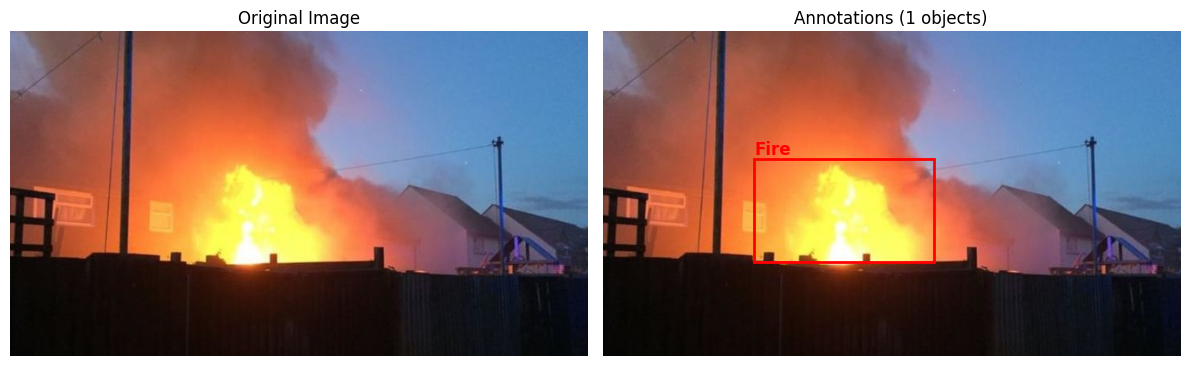

In [23]:
# Visualize a sample
def visualize_sample(dataset, idx=0):
    image, target = dataset[idx]
    
    # Convert tensor to numpy for visualization
    if isinstance(image, torch.Tensor):
        image_np = image.permute(1, 2, 0).numpy()
    else:
        image_np = np.array(image)
    
    plt.figure(figsize=(12, 6))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.title('Original Image')
    plt.axis('off')
    
    # Image with masks and boxes
    plt.subplot(1, 2, 2)
    plt.imshow(image_np)
    
    # Draw bounding boxes
    if len(target['boxes']) > 0:
        for i, box in enumerate(target['boxes']):
            x_min, y_min, x_max, y_max = box
            plt.gca().add_patch(plt.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                fill=False, color='red', linewidth=2
            ))
            plt.text(x_min, y_min - 5, f'Fire', color='red', fontsize=12, weight='bold')
    
    plt.title(f'Annotations ({len(target["boxes"])} objects)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize training sample
visualize_sample(train_dataset, idx=0)

In [24]:
# Create model
model = get_model(NUM_CLASSES)
model.to(device)

# Create optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params, 
    lr=LEARNING_RATE, 
    momentum=MOMENTUM, 
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, 
    step_size=3, 
    gamma=0.1
)

print(f"Model created with {NUM_CLASSES} classes")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model created with 2 classes
Number of parameters: 43922395
Trainable parameters: 43699995


In [25]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch}')
    
    for images, targets in progress_bar:
        # Move to device
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        losses.backward()
        optimizer.step()
        
        # Update statistics
        total_loss += losses.item()
        num_batches += 1
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{losses.item():.4f}',
            'avg_loss': f'{total_loss/num_batches:.4f}'
        })
    
    return total_loss / num_batches

In [26]:
def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc='Validation'):
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # For evaluation, we need to set model to training mode to get losses
            model.train()
            loss_dict = model(images, targets)
            model.eval()
            
            losses = sum(loss for loss in loss_dict.values())
            total_loss += losses.item()
            num_batches += 1
    
    return total_loss / num_batches

In [27]:
# Training loop
print("Starting training...")
print(f"Training for {NUM_EPOCHS} epochs")

train_losses = []
val_losses = []
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Training
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch+1)
    train_losses.append(train_loss)
    
    # Validation
    val_loss = evaluate(model, val_loader, device)
    val_losses.append(val_loss)
    
    # Update learning rate
    lr_scheduler.step()
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"New best validation loss: {best_val_loss:.4f}")
        # Create output directory if it doesn't exist
        os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'train_loss': train_loss
        }, MODEL_SAVE_PATH)
        print(f"Model saved to {MODEL_SAVE_PATH}")

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...
Training for 20 epochs

Epoch 1/20
--------------------------------------------------


Validation: 100%|██████████| 5/5 [00:12<00:00,  2.42s/it]


Train Loss: 1.3753
Val Loss: 0.7576
Learning Rate: 0.005000
New best validation loss: 0.7576
Model saved to /Users/vithikakaran/Downloads/image-seg-mask-rcnn/output/pytorch_maskrcnn_fire.pth

Epoch 2/20
--------------------------------------------------


Validation: 100%|██████████| 5/5 [00:13<00:00,  2.60s/it]


Train Loss: 0.7614
Val Loss: 0.6395
Learning Rate: 0.005000
New best validation loss: 0.6395
Model saved to /Users/vithikakaran/Downloads/image-seg-mask-rcnn/output/pytorch_maskrcnn_fire.pth

Epoch 3/20
--------------------------------------------------


...

Train Loss: 0.4602
Val Loss: 0.5283
Learning Rate: 0.000000

Epoch 19/20
--------------------------------------------------


Validation: 100%|██████████| 5/5 [00:13<00:00,  2.64s/it]


Train Loss: 0.4618
Val Loss: 0.5290
Learning Rate: 0.000000

Epoch 20/20
--------------------------------------------------


Validation: 100%|██████████| 5/5 [00:12<00:00,  2.60s/it]

Train Loss: 0.4515
Val Loss: 0.5339
Learning Rate: 0.000000

Training completed!
Best validation loss: 0.5273


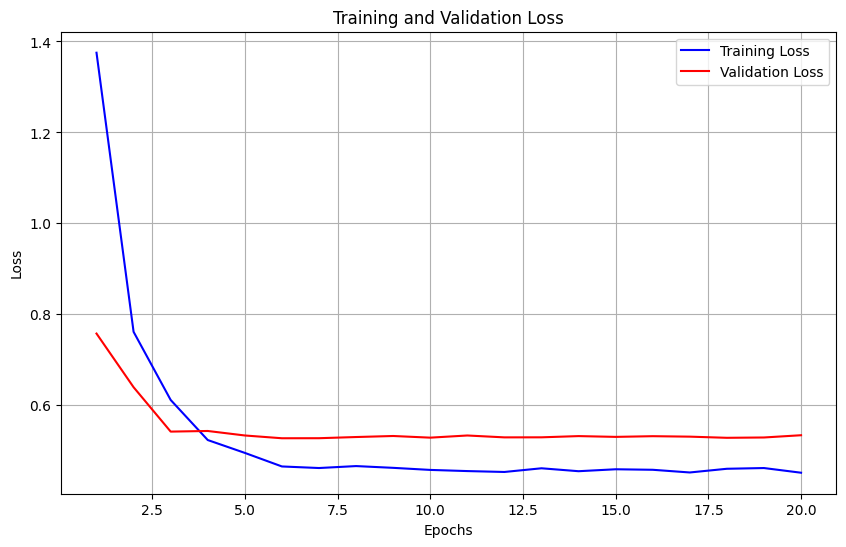

Final Training Loss: 0.4515
Final Validation Loss: 0.5339


In [37]:
# Plot training history
plt.figure(figsize=(10, 6))
epochs_range = range(1, NUM_EPOCHS + 1)
plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

In [38]:
def load_model_for_inference(model_path, num_classes, device):
    """Load trained model for inference"""
    model = get_model(num_classes)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model

# Load the best model
inference_model = load_model_for_inference(MODEL_SAVE_PATH, NUM_CLASSES, device)
print("Model loaded for inference")

Model loaded for inference


In [39]:
def predict_and_visualize(model, dataset, idx, confidence_threshold=0.5):
    """Run inference and visualize results"""
    model.eval()
    
    # Get image and ground truth
    image, target = dataset[idx]
    
    # Run inference
    with torch.no_grad():
        prediction = model([image.to(device)])[0]
    
    # Move predictions to CPU
    pred_boxes = prediction['boxes'].cpu().numpy()
    pred_scores = prediction['scores'].cpu().numpy()
    pred_labels = prediction['labels'].cpu().numpy()
    pred_masks = prediction['masks'].cpu().numpy()
    
    # Filter predictions by confidence
    keep = pred_scores >= confidence_threshold
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]
    pred_labels = pred_labels[keep]
    pred_masks = pred_masks[keep]
    
    # Convert image to numpy
    image_np = image.permute(1, 2, 0).numpy()
    
    # Create visualization
    plt.figure(figsize=(15, 5))
    
    # Original image with ground truth
    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    gt_boxes = target['boxes'].numpy()
    for box in gt_boxes:
        x_min, y_min, x_max, y_max = box
        plt.gca().add_patch(plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            fill=False, color='green', linewidth=2
        ))
    plt.title(f'Ground Truth ({len(gt_boxes)} fires)')
    plt.axis('off')
    
    # Predictions
    plt.subplot(1, 3, 2)
    plt.imshow(image_np)
    for i, (box, score) in enumerate(zip(pred_boxes, pred_scores)):
        x_min, y_min, x_max, y_max = box
        plt.gca().add_patch(plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            fill=False, color='red', linewidth=2
        ))
        plt.text(x_min, y_min - 5, f'Fire: {score:.2f}', 
                color='red', fontsize=10, weight='bold')
    plt.title(f'Predictions ({len(pred_boxes)} fires, conf>{confidence_threshold})')
    plt.axis('off')
    
    # Predicted masks
    plt.subplot(1, 3, 3)
    plt.imshow(image_np)
    if len(pred_masks) > 0:
        combined_mask = np.zeros((image_np.shape[0], image_np.shape[1]))
        for mask in pred_masks:
            combined_mask += mask[0]  # Remove channel dimension
        combined_mask = np.clip(combined_mask, 0, 1)
        plt.imshow(combined_mask, alpha=0.5, cmap='Reds')
    plt.title(f'Predicted Masks')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return pred_boxes, pred_scores, pred_labels, pred_masks

Testing on validation samples...

Validation sample 1:


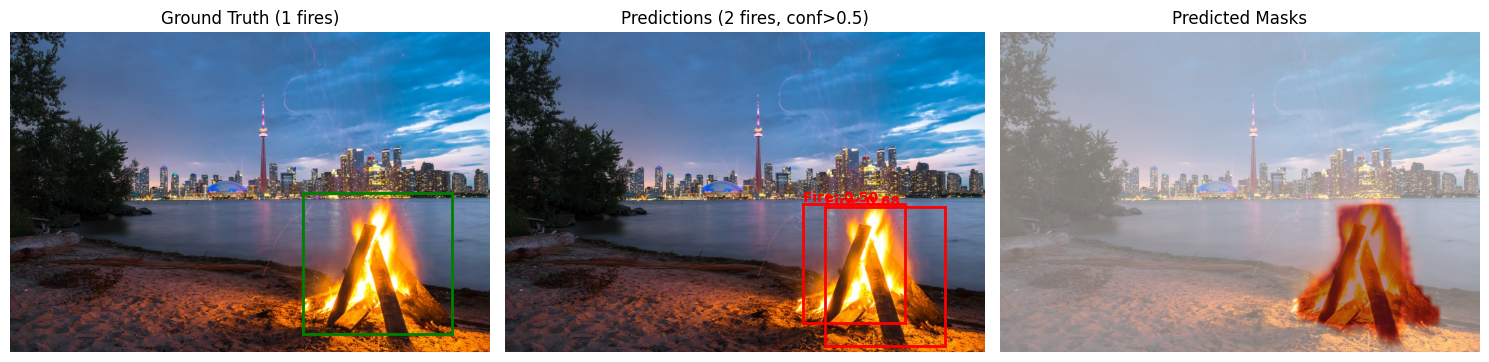

Detected 2 fire regions
Confidence scores: [0.6821757  0.50113535]

Validation sample 2:


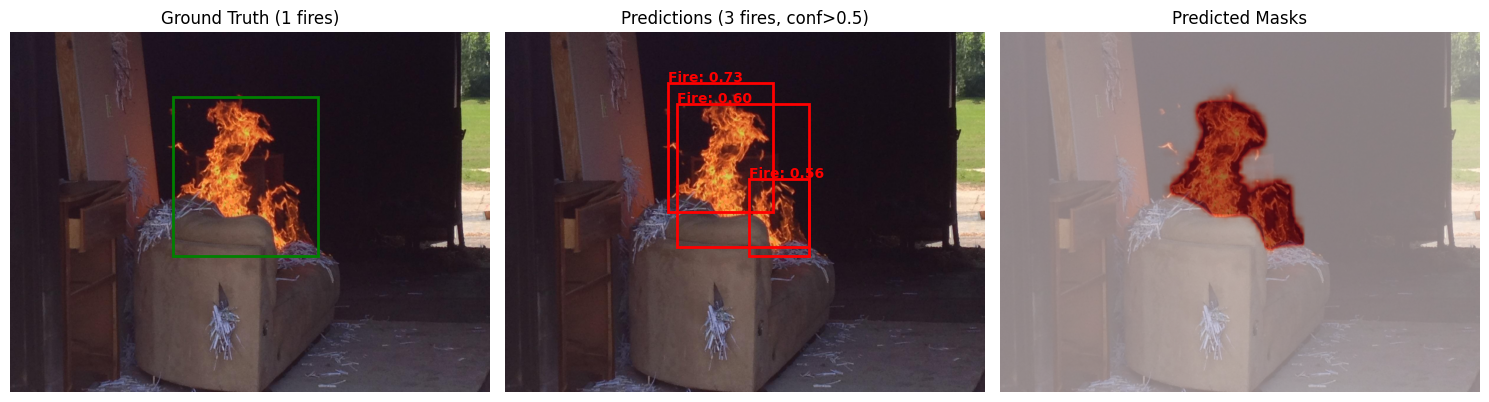

Detected 3 fire regions
Confidence scores: [0.7331738  0.60236645 0.5599632 ]

Validation sample 3:


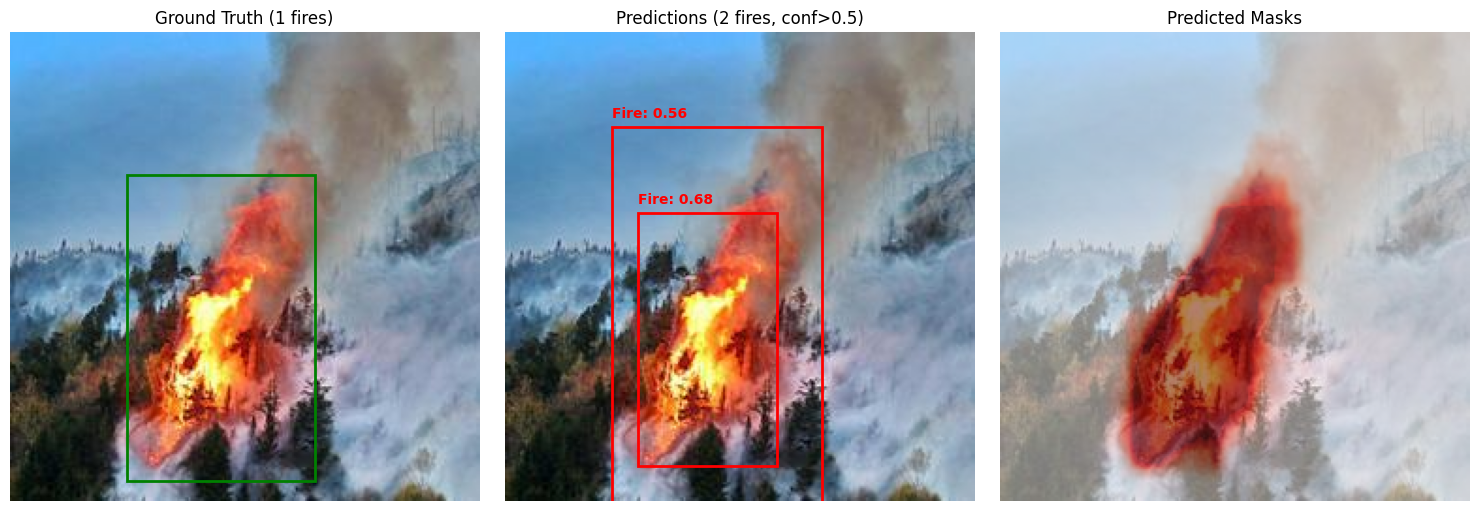

Detected 2 fire regions
Confidence scores: [0.6796713 0.560046 ]


In [40]:
# Test on validation samples
print("Testing on validation samples...")
for i in range(min(3, len(val_dataset))):
    print(f"\nValidation sample {i+1}:")
    pred_boxes, pred_scores, pred_labels, pred_masks = predict_and_visualize(
        inference_model, val_dataset, i, confidence_threshold=0.5
    )
    print(f"Detected {len(pred_boxes)} fire regions")
    if len(pred_scores) > 0:
        print(f"Confidence scores: {pred_scores}")

Testing on new image...


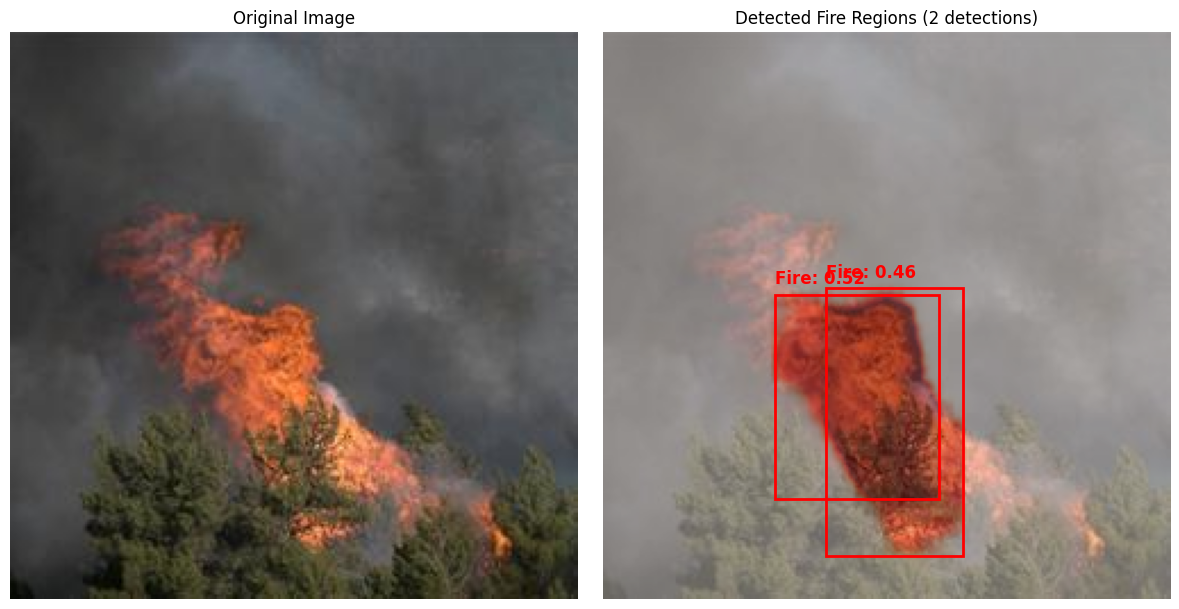

Detected 2 fire regions
Max confidence: 0.517
Min confidence: 0.464


In [41]:
# Test on a new image (if available)
def predict_on_new_image(model, image_path, confidence_threshold=0.5):
    """Predict on a new image file"""
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transforms.ToTensor()(image).unsqueeze(0).to(device)
    
    # Run inference
    with torch.no_grad():
        prediction = model(image_tensor)[0]
    
    # Move predictions to CPU
    pred_boxes = prediction['boxes'].cpu().numpy()
    pred_scores = prediction['scores'].cpu().numpy()
    pred_labels = prediction['labels'].cpu().numpy()
    pred_masks = prediction['masks'].cpu().numpy()
    
    # Filter predictions by confidence
    keep = pred_scores >= confidence_threshold
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]
    pred_labels = pred_labels[keep]
    pred_masks = pred_masks[keep]
    
    # Visualize
    plt.figure(figsize=(12, 6))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')
    
    # Predictions
    plt.subplot(1, 2, 2)
    plt.imshow(image)
    
    for i, (box, score) in enumerate(zip(pred_boxes, pred_scores)):
        x_min, y_min, x_max, y_max = box
        plt.gca().add_patch(plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            fill=False, color='red', linewidth=2
        ))
        plt.text(x_min, y_min - 5, f'Fire: {score:.2f}', 
                color='red', fontsize=12, weight='bold')
    
    # Add masks
    if len(pred_masks) > 0:
        combined_mask = np.zeros((image.size[1], image.size[0]))
        for mask in pred_masks:
            combined_mask += mask[0]
        combined_mask = np.clip(combined_mask, 0, 1)
        plt.imshow(combined_mask, alpha=0.4, cmap='Reds')
    
    plt.title(f'Detected Fire Regions ({len(pred_boxes)} detections)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return pred_boxes, pred_scores, pred_masks

# Test on test image if available
test_image_path = os.path.join(TEST_DIR, "249.jpg")
if os.path.exists(test_image_path):
    print("Testing on new image...")
    pred_boxes, pred_scores, pred_masks = predict_on_new_image(
        inference_model, test_image_path, confidence_threshold=0.3
    )
    print(f"Detected {len(pred_boxes)} fire regions")
    if len(pred_scores) > 0:
        print(f"Max confidence: {pred_scores.max():.3f}")
        print(f"Min confidence: {pred_scores.min():.3f}")
else:
    print(f"Test image not found at {test_image_path}")

In [42]:
# Model summary and performance metrics
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Framework: PyTorch {torch.__version__}")
print(f"Model: Mask R-CNN with ResNet-50 FPN backbone")
print(f"Dataset: {len(train_dataset)} training, {len(val_dataset)} validation images")
print(f"Classes: {NUM_CLASSES} (background + fire)")
print(f"Training epochs: {NUM_EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Device: {device}")
print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"\nModel saved to: {MODEL_SAVE_PATH}")
print("\nThis PyTorch implementation is:")



TRAINING SUMMARY
Framework: PyTorch 2.8.0
Model: Mask R-CNN with ResNet-50 FPN backbone
Dataset: 20 training, 10 validation images
Classes: 2 (background + fire)
Training epochs: 20
Batch size: 2
Learning rate: 0.005
Device: cpu

Final Training Loss: 0.4515
Final Validation Loss: 0.5339
Best Validation Loss: 0.5273

Model saved to: /Users/vithikakaran/Downloads/image-seg-mask-rcnn/output/pytorch_maskrcnn_fire.pth

This PyTorch implementation is:


In [43]:
# Save training configuration for future reference
config_info = {
    "model": "Mask R-CNN ResNet-50 FPN",
    "framework": f"PyTorch {torch.__version__}",
    "num_classes": NUM_CLASSES,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "device": str(device),
    "train_samples": len(train_dataset),
    "val_samples": len(val_dataset),
    "final_train_loss": train_losses[-1],
    "final_val_loss": val_losses[-1],
    "best_val_loss": best_val_loss,
    "model_path": MODEL_SAVE_PATH
}

config_path = os.path.join(ROOT_DIR, "output/pytorch_training_config.json")
with open(config_path, 'w') as f:
    json.dump(config_info, f, indent=2)

print(f"Training configuration saved to: {config_path}")

Training configuration saved to: /Users/vithikakaran/Downloads/image-seg-mask-rcnn/output/pytorch_training_config.json


In [44]:
# Test the fixed dataset loading
print("Testing fixed dataset loading...")
test_dataset = FireDataset(TRAIN_DIR)
sample_image, sample_target = test_dataset[0]
print(f"Image shape: {sample_image.shape}")
print(f"Number of objects: {len(sample_target['boxes'])}")
print(f"Boxes shape: {sample_target['boxes'].shape}")
print(f"Masks shape: {sample_target['masks'].shape}")
print(f"Labels: {sample_target['labels']}")

if len(sample_target['boxes']) > 0:
    print("Dataset loading fixed! Fire objects are now being detected.")
    print(f"First bounding box: {sample_target['boxes'][0]}")
    print(f"Mask dimensions for first object: {sample_target['masks'][0].shape}")
else:
    print("Still not detecting objects. Need further investigation.")

Testing fixed dataset loading...
Loaded 20 annotated images from /Users/vithikakaran/Downloads/image-seg-mask-rcnn/input/dataset/train
Image shape: torch.Size([3, 371, 660])
Number of objects: 1
Boxes shape: torch.Size([1, 4])
Masks shape: torch.Size([1, 371, 660])
Labels: tensor([1])
Dataset loading fixed! Fire objects are now being detected.
First bounding box: tensor([173., 145., 378., 263.])
Mask dimensions for first object: torch.Size([371, 660])


Visualizing fixed dataset:


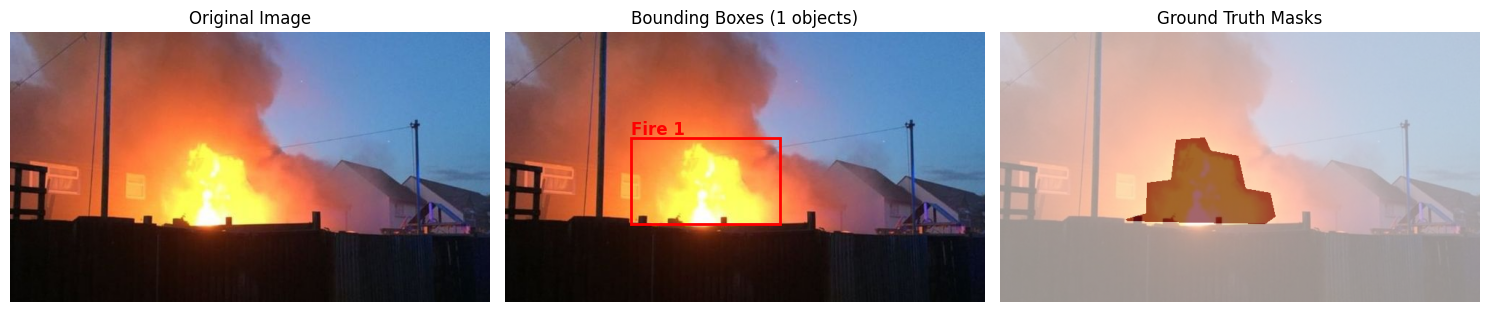


Testing multiple samples:
Sample 1: 1 fire objects detected
Sample 2: 1 fire objects detected
Sample 3: 1 fire objects detected


In [45]:
# Visualize the fixed dataset
def visualize_fixed_sample(dataset, idx=0):
    image, target = dataset[idx]
    
    # Convert tensor to numpy for visualization
    if isinstance(image, torch.Tensor):
        image_np = image.permute(1, 2, 0).numpy()
    else:
        image_np = np.array(image)
    
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title('Original Image')
    plt.axis('off')
    
    # Image with bounding boxes
    plt.subplot(1, 3, 2)
    plt.imshow(image_np)
    
    # Draw bounding boxes
    if len(target['boxes']) > 0:
        for i, box in enumerate(target['boxes']):
            x_min, y_min, x_max, y_max = box
            plt.gca().add_patch(plt.Rectangle(
                (x_min, y_min), x_max - x_min, y_max - y_min,
                fill=False, color='red', linewidth=2
            ))
            plt.text(x_min, y_min - 5, f'Fire {i+1}', color='red', fontsize=12, weight='bold')
    
    plt.title(f'Bounding Boxes ({len(target["boxes"])} objects)')
    plt.axis('off')
    
    # Image with masks
    plt.subplot(1, 3, 3)
    plt.imshow(image_np)
    
    # Draw masks
    if len(target['masks']) > 0:
        combined_mask = np.zeros((image_np.shape[0], image_np.shape[1]))
        for mask in target['masks']:
            combined_mask += mask.numpy()
        combined_mask = np.clip(combined_mask, 0, 1)
        plt.imshow(combined_mask, alpha=0.6, cmap='Reds')
    
    plt.title(f'Ground Truth Masks')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Test visualization with fixed dataset
if len(test_dataset[0][1]['boxes']) > 0:
    print("Visualizing fixed dataset:")
    visualize_fixed_sample(test_dataset, idx=0)
    print("\nTesting multiple samples:")
    for i in range(min(3, len(test_dataset))):
        sample_image, sample_target = test_dataset[i]
        print(f"Sample {i+1}: {len(sample_target['boxes'])} fire objects detected")
else:
    print("Cannot visualize - no objects detected yet")